In this notebook Seamese network model with contrastive loss for handwriting author verification trained. As backbpn ResNet50 used with freezed parameters.

First, we import our dataset. For training we use handwriting examples from 4 classic datasets: IAM, CEDAR, Bengali и Hindi

In [1]:
#importing dataset
!pip install -q gdown

file_id = "1A-MZ6zw_0uJQPuwj9GFeqwOPz2fqKOn_"
output_name = "all_data_3.zip"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1A-MZ6zw_0uJQPuwj9GFeqwOPz2fqKOn_
From (redirected): https://drive.google.com/uc?id=1A-MZ6zw_0uJQPuwj9GFeqwOPz2fqKOn_&confirm=t&uuid=c5567452-e3c8-4118-8d55-f0fbfd3dbffb
To: /content/all_data_3.zip
100% 1.76G/1.76G [00:23<00:00, 76.2MB/s]


In [2]:
import zipfile
import os

with zipfile.ZipFile("all_data_3.zip", 'r') as zip_ref:
    zip_ref.extractall("/kaggle/working/")

os.listdir("/kaggle/working/")

['all_data_3']

In [3]:
DATA_ROOT = "/kaggle/working/all_data_3"

Importing required modules

In [1]:
!pip install torchvision

In [2]:
import os
from pathlib import Path
import cv2
import numpy as np
import shutil
import random
import torch

from torch.utils.data import Dataset
import PIL
from PIL import Image
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader

import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.metrics import roc_auc_score, roc_curve


Fixing seeds

In [3]:
def set_seed(seed=42):
    """Fix all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"All seeds fixed to {seed}")
set_seed(42)

All seeds fixed to 42


Let's create class Pairs_Dataset for our data.
The dataset takes random pairs and create either positive (one author/two genuine signatures pf one author) or negative pair (two different authors/genuine and forgery of the sameauthor). The labels are created at random, the balance shall be ~50/50.
The pairs are created 'on the fly'.

In [ ]:
class Pairs_Dataset(Dataset):
    def __init__(self, root, transform=None, size=100,
                 authors_list=None, iam_ratio=0.5):
        """
        Dataset for Siamese Network with Contrastive Loss.
        Supports IAM (handwriting lines), CEDAR, Bengali, Hindi (signatures with forgeries).

        Args:
            root: Root directory containing 'iam', 'cedar', 'bengali', 'hindi' folders
            transform: Image transformations
            size: Number of pairs per epoch
            authors_list: List of author IDs to include (for train/val split)
            iam_ratio: Probability of sampling from IAM (0.5 = 50% IAM)
        """
        self.transform = transform
        self.size = size
        self.iam_ratio = iam_ratio

        # Data structures
        self.iam_data = {}
        self.cedar_original = {}
        self.cedar_forgery = {}
        self.bengali_original = {}
        self.bengali_forgery = {}
        self.hindi_original = {}
        self.hindi_forgery = {}

        #Scan IAM folder
        iam_path = os.path.join(root, 'iam')
        if os.path.exists(iam_path):
            for folder in os.listdir(iam_path):
                author_path = os.path.join(iam_path, folder)
                if not os.path.isdir(author_path):
                    continue

                author_id = folder
                valid_images = []
                for file in os.listdir(author_path):
                    if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
                        continue

                    img_path = os.path.join(author_path, file)
                    try:
                        with Image.open(img_path) as img:
                            img.verify()  
                        valid_images.append(img_path)
                    except Exception:
                        continue

                if valid_images:
                    self.iam_data[author_id] = valid_images

        #Scan CEDAR folder
        cedar_path = os.path.join(root, 'cedar')
        if os.path.exists(cedar_path):
            cedar_original_path = os.path.join(cedar_path, 'original')
            if os.path.exists(cedar_original_path):
                for author_id in os.listdir(cedar_original_path):
                    author_path = os.path.join(cedar_original_path, author_id)
                    if not os.path.isdir(author_path):
                        continue

                    valid_images = []
                    for file in os.listdir(author_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(author_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue

                    if valid_images:
                        self.cedar_original[author_id] = valid_images

            cedar_forgery_path = os.path.join(cedar_path, 'forgery')
            if os.path.exists(cedar_forgery_path):
                for author_id in os.listdir(cedar_forgery_path):
                    author_path = os.path.join(cedar_forgery_path, author_id)
                    if not os.path.isdir(author_path):
                        continue

                    valid_images = []
                    for file in os.listdir(author_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(author_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue

                    if valid_images:
                        self.cedar_forgery[author_id] = valid_images

        #Scan Bengali folder
        bengali_path = os.path.join(root, 'bengali')
        if os.path.exists(bengali_path):
            for author_id in os.listdir(bengali_path):
                author_path = os.path.join(bengali_path, author_id)
                if not os.path.isdir(author_path):
                    continue

                genuine_path = os.path.join(author_path, 'genuine')
                if os.path.exists(genuine_path):
                    valid_images = []
                    for file in os.listdir(genuine_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(genuine_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue
                    if valid_images:
                        self.bengali_original[author_id] = valid_images

                forge_path = os.path.join(author_path, 'forge')
                if os.path.exists(forge_path):
                    valid_images = []
                    for file in os.listdir(forge_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(forge_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue
                    if valid_images:
                        self.bengali_forgery[author_id] = valid_images

        #Scan Hindi folder
        hindi_path = os.path.join(root, 'hindi')
        if os.path.exists(hindi_path):
            for author_id in os.listdir(hindi_path):
                author_path = os.path.join(hindi_path, author_id)
                if not os.path.isdir(author_path):
                    continue

                genuine_path = os.path.join(author_path, 'genuine')
                if os.path.exists(genuine_path):
                    valid_images = []
                    for file in os.listdir(genuine_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(genuine_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue
                    if valid_images:
                        self.hindi_original[author_id] = valid_images

                forge_path = os.path.join(author_path, 'forge')
                if os.path.exists(forge_path):
                    valid_images = []
                    for file in os.listdir(forge_path):
                        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                            continue
                        img_path = os.path.join(forge_path, file)
                        try:
                            with Image.open(img_path) as img:
                                img.verify()
                            valid_images.append(img_path)
                        except Exception:
                            continue
                    if valid_images:
                        self.hindi_forgery[author_id] = valid_images

        #Filter by author's list
        author_set = set(authors_list)
        self.iam_data = {k: v for k, v in self.iam_data.items() if k in author_set}
        self.cedar_original = {k: v for k, v in self.cedar_original.items() if k in author_set}
        self.cedar_forgery = {k: v for k, v in self.cedar_forgery.items() if k in author_set}
        self.bengali_original = {k: v for k, v in self.bengali_original.items() if k in author_set}
        self.bengali_forgery = {k: v for k, v in self.bengali_forgery.items() if k in author_set}
        self.hindi_original = {k: v for k, v in self.hindi_original.items() if k in author_set}
        self.hindi_forgery = {k: v for k, v in self.hindi_forgery.items() if k in author_set}

        # Build author lists
        self.iam_authors = [a for a, imgs in self.iam_data.items() if len(imgs) >= 2]
        self.iam_all_authors = list(self.iam_data.keys())

        def build_signature_lists(original_dict, forgery_dict):
            authors_with_original = [a for a, imgs in original_dict.items() if len(imgs) >= 2]
            authors_with_forgery = [a for a in original_dict.keys()
                                     if a in forgery_dict
                                     and len(original_dict[a]) >= 1
                                     and len(forgery_dict[a]) >= 1]
            all_authors = list(original_dict.keys())
            return authors_with_original, authors_with_forgery, all_authors

        self.cedar_authors, self.cedar_authors_with_forgery, self.cedar_all_authors = build_signature_lists(self.cedar_original, self.cedar_forgery)
        self.bengali_authors, self.bengali_authors_with_forgery, self.bengali_all_authors = build_signature_lists(self.bengali_original, self.bengali_forgery)
        self.hindi_authors, self.hindi_authors_with_forgery, self.hindi_all_authors = build_signature_lists(self.hindi_original, self.hindi_forgery)

        # Combine signature datasets
        self.signature_datasets = []
        if self.cedar_authors or self.cedar_authors_with_forgery:
            self.signature_datasets.append(('cedar', self.cedar_original, self.cedar_forgery,
                                           self.cedar_authors, self.cedar_authors_with_forgery, self.cedar_all_authors))
        if self.bengali_authors or self.bengali_authors_with_forgery:
            self.signature_datasets.append(('bengali', self.bengali_original, self.bengali_forgery,
                                           self.bengali_authors, self.bengali_authors_with_forgery, self.bengali_all_authors))
        if self.hindi_authors or self.hindi_authors_with_forgery:
            self.signature_datasets.append(('hindi', self.hindi_original, self.hindi_forgery,
                                           self.hindi_authors, self.hindi_authors_with_forgery, self.hindi_all_authors))


    def __len__(self):
        return self.size

    def _get_iam_pair(self, label):
        """IAM: positive=same author, negative=different authors"""
        if label == 1:
            author = random.choice(self.iam_authors)
            images = self.iam_data[author]
            if len(images) < 2:
                return None, None, None
            img1_path, img2_path = random.sample(images, 2)
        else:
            if len(self.iam_all_authors) < 2:
                return None, None, None
            author1, author2 = random.sample(self.iam_all_authors, 2)
            img1_path = random.choice(self.iam_data[author1])
            img2_path = random.choice(self.iam_data[author2])
        return img1_path, img2_path, label

    def _get_signature_pair(self, dataset_name, original_dict, forgery_dict,
                           authors, authors_with_forgery, all_authors, label):
        """
        Signature datasets (CEDAR, Bengali, Hindi):
        - Positive: 2 genuine 
        - Negative: 1 genuine + 1 forgery 
        """
        if label == 1:
            author = random.choice(authors)
            original_images = original_dict[author]
            if len(original_images) < 2:
                return None, None, None
            img1_path, img2_path = random.sample(original_images, 2)
        else:
            # Negative
            author = random.choice(authors_with_forgery)
            original_images = original_dict[author]
            forgery_images = forgery_dict[author]

            img1_path = random.choice(original_images)
            img2_path = random.choice(forgery_images)

        return img1_path, img2_path, label

    def __getitem__(self, idx):
        use_iam = random.random() < self.iam_ratio
        label = random.randint(0, 1)

        img1_path, img2_path, final_label = None, None, None

        if use_iam and self.iam_authors:
            img1_path, img2_path, final_label = self._get_iam_pair(label)

        if img1_path is None and self.signature_datasets:
            dataset_name, original_dict, forgery_dict, authors, authors_with_forgery, all_authors = random.choice(self.signature_datasets)
            result = self._get_signature_pair(dataset_name, original_dict, forgery_dict,
                                              authors, authors_with_forgery, all_authors, label)
            img1_path, img2_path, final_label = result

        if img1_path is None:
            # Fallback: try any available dataset
            if self.iam_authors:
                img1_path, img2_path, final_label = self._get_iam_pair(1)
            elif self.signature_datasets:
                dataset_name, original_dict, forgery_dict, authors, authors_with_forgery, all_authors = random.choice(self.signature_datasets)
                result = self._get_signature_pair(dataset_name, original_dict, forgery_dict,
                                                  authors, authors_with_forgery, all_authors, 1)
                img1_path, img2_path, final_label = result

        img1 = Image.open(img1_path).convert('L')
        img2 = Image.open(img2_path).convert('L')

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, final_label, img1_path, img2_path

Now let's generate authors for train, val, and test in ration 70/15/15 so that they do not intersect. For further work the authors' sets are fixed and the code will be commented

In [ ]:
# iam_path = os.path.join(DATA_ROOT, 'iam')
# cedar_path = os.path.join(DATA_ROOT, 'cedar', 'original')
# bengali_path = os.path.join(DATA_ROOT, 'bengali')
# hindi_path = os.path.join(DATA_ROOT, 'hindi')

# # Get authors from each dataset
# iam_authors = os.listdir(iam_path) if os.path.exists(iam_path) else []
# cedar_authors = os.listdir(cedar_path) if os.path.exists(cedar_path) else []
# bengali_authors = os.listdir(bengali_path) if os.path.exists(bengali_path) else []
# hindi_authors = os.listdir(hindi_path) if os.path.exists(hindi_path) else []

# # Combine all authors
# all_authors = list(set(iam_authors + cedar_authors + bengali_authors + hindi_authors))

# print(f"IAM authors: {len(iam_authors)}")
# print(f"CEDAR authors: {len(cedar_authors)}")
# print(f"Bengali authors: {len(bengali_authors)}")
# print(f"Hindi authors: {len(hindi_authors)}")
# print(f"Total unique authors: {len(all_authors)}")

# # Shuffle and split
# random.shuffle(all_authors)

# # Split: 70% train, 15% val, 15% test
# train_split = int(len(all_authors) * 0.7)
# val_split = int(len(all_authors) * 0.85)

# train_authors = all_authors[:train_split]
# val_authors = all_authors[train_split:val_split]
# test_authors = all_authors[val_split:]

# print(f"\nTrain authors: {len(train_authors)} ({len(train_authors)/len(all_authors)*100:.1f}%)")
# print(f"Val authors: {len(val_authors)} ({len(val_authors)/len(all_authors)*100:.1f}%)")
# print(f"Test authors: {len(test_authors)} ({len(test_authors)/len(all_authors)*100:.1f}%)")

# # Optional: Check distribution per dataset
# print("\nDistribution per dataset")
# for dataset_name, authors_list in [('IAM', iam_authors), ('CEDAR', cedar_authors),
#                                     ('Bengali', bengali_authors), ('Hindi', hindi_authors)]:
#     train_count = len([a for a in authors_list if a in train_authors])
#     val_count = len([a for a in authors_list if a in val_authors])
#     test_count = len([a for a in authors_list if a in test_authors])
#     print(f"{dataset_name}: train={train_count}, val={val_count}, test={test_count}")

IAM authors: 657
CEDAR authors: 55
Bengali authors: 100
Hindi authors: 160
Total unique authors: 757

Train authors: 529 (69.9%)
Val authors: 114 (15.1%)
Test authors: 114 (15.1%)

Distribution per dataset
IAM: train=454, val=102, test=101
CEDAR: train=35, val=6, test=14
Bengali: train=74, val=13, test=13
Hindi: train=114, val=22, test=24


In [ ]:
train_authors=['353', '662', '546', '181', '126', '104', '15', '72', '629', '094', '10', '139', '090', '636', '160', '092', '136', '328', '190', '20', '392', '652',
               '5', '405', '378', '236', '650', '573', '162', '349', '515', '59', '128', '421', '48', '14', '3', '262', '454', '670', '281', '543', '435', '632', '393',
               '192', '594', '237', '270', '250', '153', '320', '6', '531', '418', '399', '460', '603', '027', '598', '276', '083', '216', '391', '131', '2', '496', '53',
               '618', '093', '318', '214', '189', '110', '425', '389', '420', '401', '32', '562', '170', '93', '609', '616', '357', '597', '80', '626', '332', '119', '060',
               '487', '025', '547', '390', '513', '147', '072', '553', '183', '623', '615', '500', '198', '011', '174', '647', '664', '278', '445', '290', '210', '272',
               '448', '503', '534', '69', '88', '68', '120', '24', '464', '398', '568', '070', '610', '628', '591', '31', '529', '215', '149', '138', '118', '451', '572',
               '17', '339', '049', '25', '60', '26', '243', '054', '032', '586', '471', '377', '342', '87', '58', '620', '179', '89', '109', '304', '034', '365', '373',
               '363', '169', '071', '49', '579', '382', '444', '412', '485', '310', '473', '619', '084', '518', '535', '144', '542', '280', '145', '520', '156', '099',
               '576', '570', '589', '059', '595', '208', '361', '307', '558', '101', '67', '030', '38', '115', '19', '371', '340', '567', '319', '352', '274', '530',
               '102', '259', '555', '525', '462', '226', '27', '539', '041', '607', '508', '344', '182', '79', '288', '085', '095', '239', '267', '584', '92', '639',
               '410', '70', '184', '121', '492', '114', '509', '053', '334', '246', '490', '449', '255', '440', '185', '580', '294', '477', '495', '436', '291', '641',
               '33', '35', '21', '089', '103', '289', '370', '221', '466', '242', '076', '423', '379', '020', '008', '224', '019', '248', '98', '067', '483', '37', '663',
               '064', '582', '086', '031', '23', '563', '611', '305', '96', '472', '283', '043', '414', '141', '34', '151', '065', '621', '55', '91', '260', '231', '048',
               '478', '499', '606', '056', '354', '229', '045', '81', '096', '343', '408', '264', '155', '596', '253', '461', '235', '042', '73', '347', '482', '475',
               '386', '197', '394', '431', '65', '634', '416', '90', '36', '303', '122', '018', '517', '668', '252', '097', '228', '107', '413', '082', '556', '203',
               '494', '285', '028', '191', '592', '256', '578', '171', '002', '188', '526', '367', '116', '522', '234', '71', '30', '035', '364', '268', '327', '484',
               '146', '312', '533', '4', '046', '209', '433', '86', '402', '350', '640', '428', '453', '279', '536', '441', '037', '614', '47', '296', '159', '315', '062',
               '000', '407', '549', '080', '335', '079', '504', '659', '419', '117', '540', '081', '452', '351', '521', '384', '051', '648', '524', '036', '411', '75',
               '645', '325', '559', '211', '583', '527', '1', '502', '447', '7', '193', '565', '99', '152', '551', '608', '403', '195', '298', '006', '004', '077',
               '187', '301', '491', '366', '130', '538', '206', '324', '175', '098', '247', '180', '222', '251', '28', '63', '474', '671', '545', '088', '052', '388',
               '257', '123', '172', '486', '83', '554', '41', '417', '430', '660', '023', '56', '380', '40', '227', '566', '026', '219', '481', '575', '309', '489', '638',
               '148', '45', '258', '249', '200', '356', '331', '263', '232', '630', '063', '164', '544', '168', '359', '443', '047', '186', '85', '470', '336', '176',
               '078', '651', '196', '577', '455', '012', '666', '571', '317', '376', '429', '655', '314', '52', '600', '058', '212', '016', '022', '217', '94', '106',
               '44', '244', '77', '199', '8', '329', '22', '519', '561', '643', '64', '137', '501', '493']
val_authors=['456', '9', '426', '97', '322', '133', '13', '021', '157', '355', '166', '375', '627', '345', '605', '140', '135', '161', '163', '593', '476', '84', '225',
             '223', '62', '213', '512', '266', '537', '446', '100', '346', '422', '233', '613', '167', '261', '360', '127', '633', '292', '442', '341', '564', '468',
             '654', '467', '302', '330', '220', '465', '458', '18', '299', '326', '286', '014', '528', '635', '007', '569', '548', '333', '57', '207', '581', '039',
             '50', '338', '439', '205', '54', '552', '173', '348', '644', '488', '665', '362', '498', '409', '637', '587', '075', '300', '108', '642', '74', '400',
             '76', '074', '125', '51', '091', '017', '295', '245', '624', '142', '383', '585', '457', '230', '040', '497', '073', '432', '369', '275', '506', '201',
             '241', '129', '218']
test_authors=['43', '134', '516', '055', '204', '313', '523', '068', '404', '372', '601', '395', '469', '617', '009', '254', '588', '194', '337', '178', '511', '29',
              '015', '82', '287', '124', '599', '112', '39', '541', '293', '010', '143', '625', '132', '95', '158', '649', '622', '316', '282', '667', '532', '321',
              '177', '013', '505', '297', '631', '42', '658', '66', '368', '202', '510', '590', '165', '459', '154', '434', '61', '005', '397', '105', '602', '265',
              '46', '396', '387', '450', '323', '001', '087', '240', '113', '066', '604', '044', '061', '550', '463', '653', '033', '273', '669', '514', '150', '024',
              '424', '479', '069', '16', '574', '308', '238', '038', '415', '560', '385', '557', '277', '480', '612', '661', '111', '12', '427', '78', '050', '003',
              '269', '11', '406', '029']


Let's create transformations. For train we use rotation and random affine augmentations. For the model images 224*224 used

In [4]:
train_transform = T.Compose([
    T.Resize((224, 224)),  #use 224*224 for the model
    T.RandomRotation(3),
    T.RandomAffine(0, translate=(0.02, 0.02), scale=(0.98, 1.02)),
    T.ToTensor(),
    T.Normalize(0.485, 0.229)
])

val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(0.485, 0.229)
])

test_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(0.485, 0.229)
])

Now we create train dataset. The dataset is nor fixed, at each iteration random pairs are created

In [ ]:
train_dataset = Pairs_Dataset(
    root=DATA_ROOT,
    transform=train_transform,
    size=5000,
    authors_list=train_authors
)

For val and test sets we fix the dataset. For the first time we generate them useing Pairs_Dataset above. The the labels and paths to images fixed and saveed to be reused for other models. To reuse we create SavedPairsDataset to recreate datasets from saved pkl.files.

In [5]:
class SavedPairsDataset(Dataset):
    def __init__(self, pairs_file, transform=None):
        with open(pairs_file, 'rb') as f:
            self.pairs = pickle.load(f)
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img1_path, img2_path, label = self.pairs[idx]

        img1 = Image.open(img1_path).convert('L')
        img2 = Image.open(img2_path).convert('L')

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, label

In [ ]:
# Creating of datasets for the first time
# val_pairs = []
# test_pairs = []
# temp_dataset_val = Pairs_Dataset(root=DATA_ROOT, transform=None, train=False,
#                               size=2000, authors_list=val_authors)
# temp_dataset_test = Pairs_Dataset(root=DATA_ROOT, transform=None, train=False,
#                               size=1000, authors_list=test_authors)
# for i in range(len(temp_dataset_val)):
#     img1, img2, label, p1, p2 = temp_dataset_val[i]
#     val_pairs.append((p1, p2, label))

# for i in range(len(temp_dataset_test)):
#     img1, img2, label, p1, p2 = temp_dataset_test[i]
#     test_pairs.append((p1, p2, label))

# with open('val_pairs.pkl', 'wb') as f:
#     pickle.dump(val_pairs, f)

# with open('test_pairs.pkl', 'wb') as f:
#     pickle.dump(test_pairs, f)

val_dataset = SavedPairsDataset('val_pairs.pkl', transform=val_transform)
test_dataset = SavedPairsDataset('test_pairs.pkl', transform=test_transform)

In [ ]:
val_dataset[0]

(tensor([[[1.9235, 1.9235, 1.9407,  ..., 1.9749, 1.9407, 1.9578],
          [1.8722, 1.8893, 1.9235,  ..., 2.0092, 1.9749, 1.9578],
          [1.9064, 1.9235, 1.9235,  ..., 1.9920, 1.9578, 1.9407],
          ...,
          [1.9578, 1.9578, 1.9578,  ..., 1.9749, 1.9920, 2.0434],
          [1.9407, 1.9407, 1.9578,  ..., 1.9749, 1.9920, 1.9920],
          [1.9920, 1.9578, 1.9749,  ..., 1.9749, 1.9749, 2.0092]]]),
 tensor([[[2.2489, 2.2318, 2.2318,  ..., 2.2318, 2.2318, 2.2147],
          [2.2489, 2.2318, 2.2318,  ..., 2.2489, 2.2318, 2.2489],
          [2.2318, 2.2147, 2.2147,  ..., 2.2318, 2.2318, 2.2318],
          ...,
          [2.2489, 2.2147, 2.2318,  ..., 2.2318, 2.2318, 2.2318],
          [2.2318, 2.2318, 2.2318,  ..., 2.2318, 2.2489, 2.2489],
          [2.1975, 2.1975, 2.1975,  ..., 2.2318, 2.2489, 2.2318]]]),
 0)

Let's look at the example of data. The val and test datasets are fixed, the train dataset is created on the fly

Label: 0
Size img1: torch.Size([1, 224, 224])
Size img2: torch.Size([1, 224, 224])


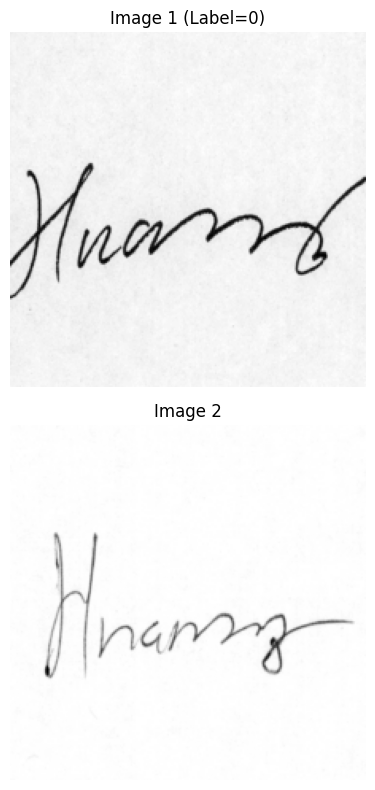

In [ ]:
img1, img2, label = val_dataset[0]

print(f"Label: {label}")
print(f"Size img1: {img1.shape}")
print(f"Size img2: {img2.shape}")

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.imshow(img1[0], cmap='gray')
plt.title(f"Image 1 (Label={label})")
plt.axis('off')

plt.subplot(2, 1, 2)
plt.imshow(img2[0], cmap='gray')
plt.title("Image 2")
plt.axis('off')

plt.tight_layout()
plt.show()

Let's make sure that the datasets are balanced

In [ ]:
labels=[]

for i in range(len(train_dataset)):
  labels.append(train_dataset[i][2])

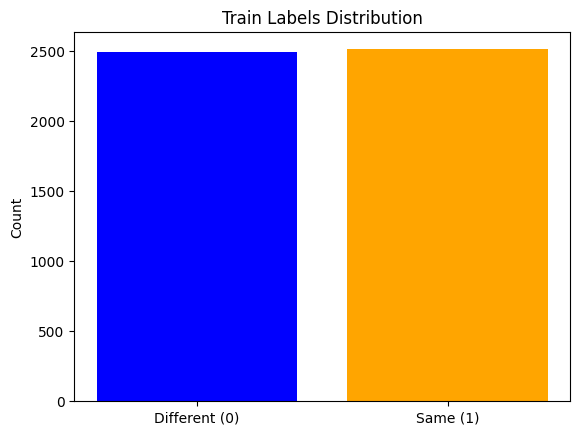

In [ ]:
counts = [labels.count(0), labels.count(1)]

plt.bar(['Different (0)', 'Same (1)'], counts, color=['blue', 'orange'])
plt.ylabel('Count')
plt.title('Train Labels Distribution')
plt.show()

In [ ]:
labels_val=[]

for i in range(len(val_dataset)):
  labels_val.append(val_dataset[i][2])

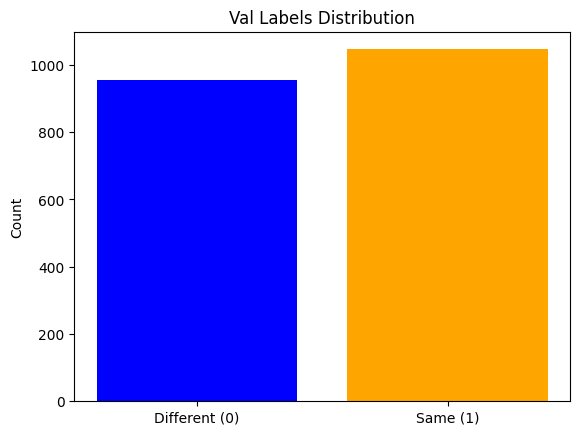

In [ ]:
counts = [labels_val.count(0), labels_val.count(1)]

plt.bar(['Different (0)', 'Same (1)'], counts, color=['blue', 'orange'])
plt.ylabel('Count')
plt.title('Val Labels Distribution')
plt.show()

In [ ]:
labels_test=[]

for i in range(len(test_dataset)):
  labels_test.append(test_dataset[i][2])

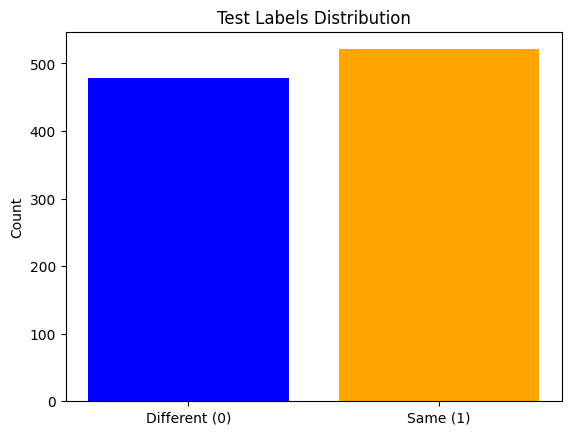

In [ ]:
counts = [labels_test.count(0), labels_test.count(1)]

plt.bar(['Different (0)', 'Same (1)'], counts, color=['blue', 'orange'])
plt.ylabel('Count')
plt.title('Test Labels Distribution')
plt.show()

There are very little imbalance which is insignification for our task

Now we create dataloaders

In [ ]:
# creating DataLoader
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

Let's create class for our model. The class has freeze_mode parameter (aggressive or moderate), in aggressive mode we freeze all layer except for the last one (layer4), in moderate except for 2 lasts (layer3 and 4layers).For training we use Contrastive loss. To calculate metrics distance between embeddings used, threshold is set using iteration.

In [6]:
class SiameseNetwork(nn.Module):
    def __init__(self, embedding_size=256, freeze_mode="aggressive"):
        super(SiameseNetwork, self).__init__()

        # Load pretrained ResNet-50
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        # Adapt first layer for single channel
        original_conv1 = backbone.conv1
        backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        backbone.conv1.weight.data = original_conv1.weight.data.mean(dim=1, keepdim=True)

        # Remove final FC layer
        self.resnet = nn.Sequential(*list(backbone.children())[:-1])

        # Freeze layers based on mode
        if freeze_mode == "aggressive":
            # Freeze all layers
            for param in self.resnet.parameters():
                param.requires_grad = False

            # Unfreeze layer4 (index 7) and conv1 (index 0)
            for name, param in self.resnet.named_parameters():
                if name.startswith('7.'):  # layer4
                    param.requires_grad = True

            # Unfreeze conv1 (index 0)
            for param in self.resnet[0].parameters():
                param.requires_grad = True

        elif freeze_mode == "moderate":
            # Freeze all layers first
            for param in self.resnet.parameters():
                param.requires_grad = False

            # Unfreeze layer3 (index 6) and layer4 (index 7)
            for name, param in self.resnet.named_parameters():
                if name.startswith('6.') or name.startswith('7.'):
                    param.requires_grad = True

            # Unfreeze conv1 (index 0)
            for param in self.resnet[0].parameters():
                param.requires_grad = True

        elif freeze_mode == "none":
            # All layers trainable
            pass

        # Embedding head
        self.embedding = nn.Sequential(
            nn.Linear(2048, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, embedding_size)
        )

        self.embedding_size = embedding_size

        # Print statistics
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"Freeze mode: {freeze_mode}")
        print(f"Total parameters: {total:,}")
        print(f"Trainable parameters: {trainable:,} ({100*trainable/total:.1f}%)")

    def forward_one(self, x):
        x = self.resnet(x)
        x = x.view(x.size(0), -1)
        x = self.embedding(x)
        return F.normalize(x, p=2, dim=1)

    def forward(self, x1, x2):
        out1 = self.forward_one(x1)
        out2 = self.forward_one(x2)
        return out1, out2

Let's create class of contrastive loss, eucledian distance used

In [ ]:
class ContrastiveLoss(nn.Module):
    """Contrastive loss"""

    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        # Eucledian distance used
        distance = F.pairwise_distance(output1, output2)

        loss = label * torch.pow(distance, 2) / 2
        loss += (1 - label) * torch.pow(torch.clamp(self.margin - distance, min=0.0), 2) / 2

        return loss.mean()

Let's create function for training and calculating metrics.


train_model() trains a Siamese network with:

Contrastive Loss (margin=1.0) to pull same-author embeddings together and push different-author embeddings apart.

AdamW optimizer + ReduceLROnPlateau scheduler.

Tracking of training/validation: loss, accuracy (fixed threshold 0.5), ROC-AUC, and EER.

Distances (Euclidean) are computed between embedding pairs, then used for all metrics.

The best model is saved based on highest validation ROC-AUC.

Returns training history for analysis.


calculate_eer() computes the Equal Error Rate from distances and labels, converting distances to similarity scores (negative distances) for ROC calculation, then finds the threshold where FPR and FNR are closest.

The model is trained for 30 epochs, learning rate 0.001, weight decay 0.0001.

In [7]:
def calculate_eer(labels, distances):
    """
    Calculate Equal Error Rate (EER) from distances

    Args:
        labels: true labels (0 or 1, where 1 = same author, 0 = different authors)
        distances: Euclidean distances between embeddings (smaller = more similar)

    Returns:
        eer: Equal Error Rate
    """
    # For ROC curve, we need scores where higher = more similar
    # Since distance is smaller = more similar, we use negative distances as scores
    scores = -np.array(distances)

    fpr, tpr, thresholds = roc_curve(labels, scores)
    fnr = 1 - tpr

    # Find the threshold where FPR and FNR are closest
    eer_idx = np.nanargmin(np.absolute(fnr - fpr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
    return eer


def train_model(
    model,
    train_loader,
    val_loader,
    epochs=50,
    lr=0.001,
    device=None,
    save_path='best_model.pth',
    weight_decay=0.01
):
    """Training Siamese network with Contrastive Loss only (no BCE)"""
    # Move model to device
    model = model.to(device)

    # Optimizer and scheduler
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2, threshold=0.01
    )

    #Contrastive Loss
    contrastive_loss = ContrastiveLoss(margin=1.0)

    # History tracking
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_roc_auc': [], 'val_roc_auc': [],
        'train_eer': [], 'val_eer': [],
        'lr': []
    }
    best_val_roc_auc = 0.0

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        train_labels = []
        train_distances = []  # store distances for ROC-AUC

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        for img1, img2, labels in pbar:
            img1 = img1.to(device)
            img2 = img2.to(device)
            labels = labels.float().to(device)

            optimizer.zero_grad()

            # Forward pass - model returns only embeddings
            emb1, emb2 = model(img1, img2)

            # Compute Euclidean distance between embeddings
            distances = torch.norm(emb1 - emb2, p=2, dim=1)

            #Contrastive Loss
            loss = contrastive_loss(emb1, emb2, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            # For accuracy: threshold on distance (smaller distance = same author)
            # We'll use a simple threshold of 0.5 for training monitoring
            # (optimal threshold will be found on validation)
            predicted = (distances <= 0.5).float()
            train_correct += (predicted == labels).sum().item()
            train_total += labels.size(0)

            train_labels.extend(labels.cpu().numpy())
            train_distances.extend(distances.detach().cpu().numpy())

            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{train_correct/train_total:.3f}'
            })

        train_acc = train_correct / train_total
        train_loss_avg = train_loss / len(train_loader)

        # Calculate ROC-AUC from distances (smaller distance = more similar)
        train_roc_auc = roc_auc_score(train_labels, [-d for d in train_distances]) if len(set(train_labels)) > 1 else 0.5
        train_eer = calculate_eer(train_labels, train_distances)

        # Validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        val_labels = []
        val_distances = []

        with torch.no_grad():
            for img1, img2, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                img1 = img1.to(device)
                img2 = img2.to(device)
                labels = labels.float().to(device)

                emb1, emb2 = model(img1, img2)

                distances = torch.norm(emb1 - emb2, p=2, dim=1)
                loss = contrastive_loss(emb1, emb2, labels)

                val_loss += loss.item()

                # For accuracy with fixed threshold 0.5 (for monitoring)
                predicted = (distances <= 0.5).float()
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

                val_labels.extend(labels.cpu().numpy())
                val_distances.extend(distances.cpu().numpy())

        val_acc = val_correct / val_total
        val_loss_avg = val_loss / len(val_loader)
        val_roc_auc = roc_auc_score(val_labels, [-d for d in val_distances]) if len(set(val_labels)) > 1 else 0.5
        val_eer = calculate_eer(val_labels, val_distances)

        # Update scheduler
        scheduler.step(val_loss_avg)

        # Save history
        history['train_loss'].append(train_loss_avg)
        history['val_loss'].append(val_loss_avg)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_roc_auc'].append(train_roc_auc)
        history['val_roc_auc'].append(val_roc_auc)
        history['train_eer'].append(train_eer)
        history['val_eer'].append(val_eer)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        # Print results
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"  Train Loss: {train_loss_avg:.4f}, Train Acc: {train_acc:.4f}, ROC-AUC: {train_roc_auc:.4f}, EER: {train_eer:.4f}")
        print(f"  Val Loss:   {val_loss_avg:.4f}, Val Acc:   {val_acc:.4f}, ROC-AUC: {val_roc_auc:.4f}, EER: {val_eer:.4f}")
        print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")

        # Save best model by ROC-AUC
        if val_roc_auc > best_val_roc_auc:
            best_val_roc_auc = val_roc_auc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'val_roc_auc': val_roc_auc,
                'val_eer': val_eer
            }, save_path)
            print(f"Model saved. Val Acc: {val_acc:.4f}, Val ROC-AUC: {val_roc_auc:.4f}, Val EER: {val_eer:.4f}")

    return history

Now let's train our model with aggressive freeze_mode

In [ ]:
model_agr_freezed = SiameseNetwork(embedding_size=256, freeze_mode='aggressive')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Train
history_agr_freezed = train_model(
    model=model_agr_freezed,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=30,
    lr=0.001,
    device=device,
    save_path='best_model_agr_freezed.pth',
    weight_decay=0.0001)

print(f"\nBest Val ROC-AUC: {max(history_agr_freezed['val_roc_auc'])*100:.2f}%")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 135MB/s]


Freeze mode: aggressive
Total parameters: 25,862,336
Trainable parameters: 17,328,448 (67.0%)


Epoch 1/30 [Val]: 100%|██████████| 250/250 [00:28<00:00,  8.74it/s]



Epoch 1/30
  Train Loss: 0.1163, Train Acc: 0.5880, ROC-AUC: 0.6434, EER: 0.4104
  Val Loss:   0.1507, Val Acc:   0.6040, ROC-AUC: 0.7468, EER: 0.3305
  LR: 0.001000
Model saved. Val Acc: 0.6040, Val ROC-AUC: 0.7468, Val EER: 0.3305


...


Epoch 28/30
  Train Loss: 0.0408, Train Acc: 0.8972, ROC-AUC: 0.9590, EER: 0.1046
  Val Loss:   0.0405, Val Acc:   0.8935, ROC-AUC: 0.9637, EER: 0.0965
  LR: 0.000250
Model saved. Val Acc: 0.8935, Val ROC-AUC: 0.9637, Val EER: 0.0965


Epoch 29/30 [Val]: 100%|██████████| 250/250 [00:29<00:00,  8.61it/s]



Epoch 29/30
  Train Loss: 0.0382, Train Acc: 0.9054, ROC-AUC: 0.9652, EER: 0.0958
  Val Loss:   0.0422, Val Acc:   0.8920, ROC-AUC: 0.9567, EER: 0.1120
  LR: 0.000125


Epoch 30/30 [Val]: 100%|██████████| 250/250 [00:28<00:00,  8.70it/s]


Epoch 30/30
  Train Loss: 0.0371, Train Acc: 0.9120, ROC-AUC: 0.9670, EER: 0.0924
  Val Loss:   0.0400, Val Acc:   0.9015, ROC-AUC: 0.9627, EER: 0.0935
  LR: 0.000125

Best Val ROC-AUC: 96.37%


In [ ]:
history_agr_freezed

{'train_loss': [0.11632603687644005,
  0.10624937074184418,
  0.0978118505448103,
  0.09087885293066501,
  0.08994071687087417,
  0.0858986955434084,
  0.08130027970522642,
  0.0783944066926837,
  0.07405096098631621,
  0.07264745571315288,
  0.07015991815775632,
  0.06746550049185752,
  0.06341832602620125,
  0.062078444033116104,
  0.06134690334573388,
  0.05867233730368316,
  0.05935841303244233,
  0.05553367783464491,
  0.05054632620960474,
  0.04921497836783528,
  0.04819977894350886,
  0.04747716345638037,
  0.04705121495984495,
  0.0458671702414751,
  0.04160008013471961,
  0.04554123621433973,
  0.04059788537565619,
  0.04080929977595806,
  0.03819211645498872,
  0.037077713100705297],
 'val_loss': [0.150690025633201,
  0.10101273866370321,
  0.08678778493404389,
  0.08959592126496137,
  0.07551629350706934,
  0.07363880219869316,
  0.07120173295680433,
  0.0673307548505254,
  0.060352594193536786,
  0.06602870340598747,
  0.05487626995146275,
  0.07285656952811405,
  0.0741213

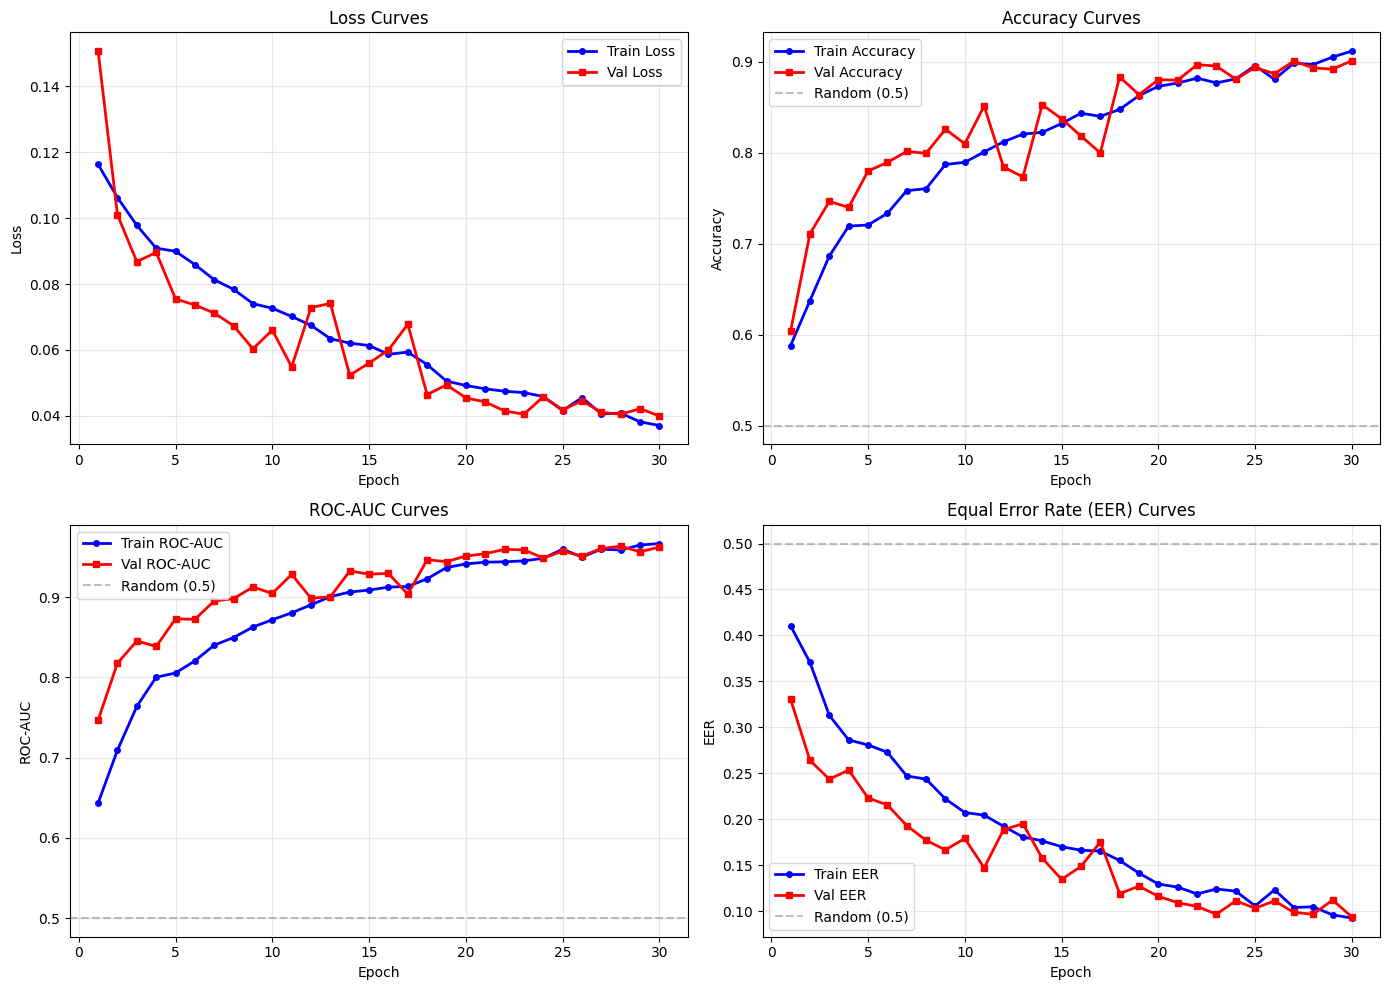

In [ ]:
epochs = range(1, len(history_agr_freezed['train_loss']) + 1)

train_loss = history_agr_freezed['train_loss']
val_loss = history_agr_freezed['val_loss']
train_acc = history_agr_freezed['train_acc']
val_acc = history_agr_freezed['val_acc']
train_roc_auc = history_agr_freezed['train_roc_auc']
val_roc_auc = history_agr_freezed['val_roc_auc']
train_eer = history_agr_freezed['train_eer']
val_eer = history_agr_freezed['val_eer']
lr = history_agr_freezed['lr']

# Create figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss Curves
axes[0, 0].plot(epochs, train_loss, 'b-o', label='Train Loss', linewidth=2, markersize=4)
axes[0, 0].plot(epochs, val_loss, 'r-s', label='Val Loss', linewidth=2, markersize=4)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curves')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Accuracy Curves
axes[0, 1].plot(epochs, train_acc, 'b-o', label='Train Accuracy', linewidth=2, markersize=4)
axes[0, 1].plot(epochs, val_acc, 'r-s', label='Val Accuracy', linewidth=2, markersize=4)
axes[0, 1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy Curves')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. ROC-AUC Curves
axes[1, 0].plot(epochs, train_roc_auc, 'b-o', label='Train ROC-AUC', linewidth=2, markersize=4)
axes[1, 0].plot(epochs, val_roc_auc, 'r-s', label='Val ROC-AUC', linewidth=2, markersize=4)
axes[1, 0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('ROC-AUC')
axes[1, 0].set_title('ROC-AUC Curves')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. EER Curves
axes[1, 1].plot(epochs, train_eer, 'b-o', label='Train EER', linewidth=2, markersize=4)
axes[1, 1].plot(epochs, val_eer, 'r-s', label='Val EER', linewidth=2, markersize=4)
axes[1, 1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('EER')
axes[1, 1].set_title('Equal Error Rate (EER) Curves')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_metrics_freezed_agr.png', dpi=150, bbox_inches='tight')
plt.show()

Now ler's test on test set

In [8]:
def calculate_eer(labels, scores):
    """Calculating (EER)"""
    fpr, tpr, thresholds = roc_curve(labels, scores)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.absolute(fnr - fpr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
    return eer

def evaluate_siamese_model(model, dataloader, device):
    """
        Evaluation of Siamese model on test set.
        Works with SiameseNetwork that returns embeddings.
        Classification threshold = 0.5

        Args:
            model: trained SiameseNetwork model
            dataloader: DataLoader with triples (img1, img2, label)
            device: cuda or cpu

        Returns:
            dict with metrics
    """
    model.eval()

    all_distances = []
    all_labels = []

    with torch.no_grad():
        for img1, img2, labels in dataloader:
            img1 = img1.to(device)
            img2 = img2.to(device)
            labels = labels.float().to(device)

            # Getting embeddings
            emb1, emb2 = model(img1, img2)

            #Calculating Eucledian space
            distances = torch.norm(emb1 - emb2, p=2, dim=1)

            all_distances.extend(distances.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_distances = np.array(all_distances)
    all_labels = np.array(all_labels)

    # Converting distance into similarity
    # The less distance, the more similarity
    similarity = 1 - (all_distances / 2)  #Normalizing to (0, 2)

    # ROC-AUC 
    roc_auc = roc_auc_score(all_labels, similarity)

    # EER 
    eer = calculate_eer(all_labels, similarity)

    # Accuracy
    threshold = 0.5
    predictions = (similarity >= threshold).astype(int)
    accuracy = accuracy_score(all_labels, predictions)

    pos_distances = all_distances[all_labels == 1]
    neg_distances = all_distances[all_labels == 0]

    results = {
        'roc_auc': roc_auc,
        'eer': eer,
        'accuracy': accuracy,
        'threshold': threshold,
        'mean_distance_same_author': pos_distances.mean() if len(pos_distances) > 0 else 0,
        'mean_distance_diff_author': neg_distances.mean() if len(neg_distances) > 0 else 0,
        'std_distance_same': pos_distances.std() if len(pos_distances) > 0 else 0,
        'std_distance_diff': neg_distances.std() if len(neg_distances) > 0 else 0,
        'distance_gap': (neg_distances.mean() - pos_distances.mean()) if len(pos_distances) > 0 and len(neg_distances) > 0 else 0,
        'num_samples': len(all_labels),
        'num_positive': int((all_labels == 1).sum()),
        'num_negative': int((all_labels == 0).sum())
    }

    return results


In [ ]:
result = evaluate_siamese_model(model_agr_freezed, test_loader, device)


print(f"ROC-AUC: {result['roc_auc']:.4f}")
print(f"EER: {result['eer']:.4f}")
print(f"Accuracy: {result['accuracy']:.4f}")
print(f"Mean distance (positive pair): {result['mean_distance_same_author']:.4f}")
print(f"Mean distance (negative pair): {result['mean_distance_diff_author']:.4f}")


ROC-AUC: 0.9549
EER (Equal Error Rate): 0.1170
Accuracy: 0.7510
Среднее расстояние (позитивная пара): 0.1875
Среднее расстояние (негативная пара): 0.9902


Now let's train the model without freezing and compare results

In [ ]:
model_not_freezed = SiameseNetwork(embedding_size=256, freeze_mode=None)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Train
history_not_freezed = train_model(
    model=model_not_freezed,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=30,
    lr=0.001,
    device=device,
    save_path='best_model_not_freezed.pth',
    weight_decay=0.0001)

print(f"\nBest Val ROC-AUC: {max(history_not_freezed['val_roc_auc'])*100:.2f}%")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 116MB/s]


Freeze mode: None
Total parameters: 25,862,336
Trainable parameters: 25,862,336 (100.0%)


Epoch 1/30 [Val]: 100%|██████████| 250/250 [00:29<00:00,  8.62it/s]



Epoch 1/30
  Train Loss: 0.1182, Train Acc: 0.5808, ROC-AUC: 0.6225, EER: 0.4254
  Val Loss:   0.1429, Val Acc:   0.6365, ROC-AUC: 0.7898, EER: 0.2965
  LR: 0.001000
Model saved. Val Acc: 0.6365, Val ROC-AUC: 0.7898, Val EER: 0.2965


...


Epoch 28/30
  Train Loss: 0.0520, Train Acc: 0.8640, ROC-AUC: 0.9324, EER: 0.1400
  Val Loss:   0.0483, Val Acc:   0.8760, ROC-AUC: 0.9458, EER: 0.1285
  LR: 0.000125


Epoch 29/30 [Val]: 100%|██████████| 250/250 [00:29<00:00,  8.42it/s]



Epoch 29/30
  Train Loss: 0.0550, Train Acc: 0.8500, ROC-AUC: 0.9260, EER: 0.1506
  Val Loss:   0.0485, Val Acc:   0.8690, ROC-AUC: 0.9455, EER: 0.1320
  LR: 0.000125


Epoch 30/30 [Val]: 100%|██████████| 250/250 [00:29<00:00,  8.60it/s]


Epoch 30/30
  Train Loss: 0.0531, Train Acc: 0.8570, ROC-AUC: 0.9302, EER: 0.1452
  Val Loss:   0.0507, Val Acc:   0.8635, ROC-AUC: 0.9390, EER: 0.1315
  LR: 0.000125

Best Val ROC-AUC: 94.66%


In [ ]:
history_not_freezed

{'train_loss': [0.11816841580271721,
  0.10860076268315315,
  0.11365738768577575,
  0.10837158560752869,
  0.0998304764777422,
  0.09047650466263295,
  0.08846112624704838,
  0.08330111436396838,
  0.07964861816763878,
  0.07444827039092779,
  0.07319914333154448,
  0.07341192258670926,
  0.07109514379799366,
  0.06893188357427717,
  0.06962997025921941,
  0.06833198119550943,
  0.06530496822148561,
  0.06263438991978765,
  0.06141498627960682,
  0.06178011499792337,
  0.06149485298767686,
  0.05854944844841957,
  0.05768493083119392,
  0.05685032271370292,
  0.05559704628251493,
  0.05561588583737612,
  0.05716762504838407,
  0.05195520926490426,
  0.055044073792546985,
  0.05311791569571942],
 'val_loss': [0.1429384906035848,
  0.1344059406253509,
  0.1244971115924418,
  0.11827919282019138,
  0.09485597817692906,
  0.1124210922117345,
  0.12417628701776266,
  0.10838399664405733,
  0.07883025904372334,
  0.07358811374753714,
  0.06419056301750242,
  0.05650770256854594,
  0.0529348

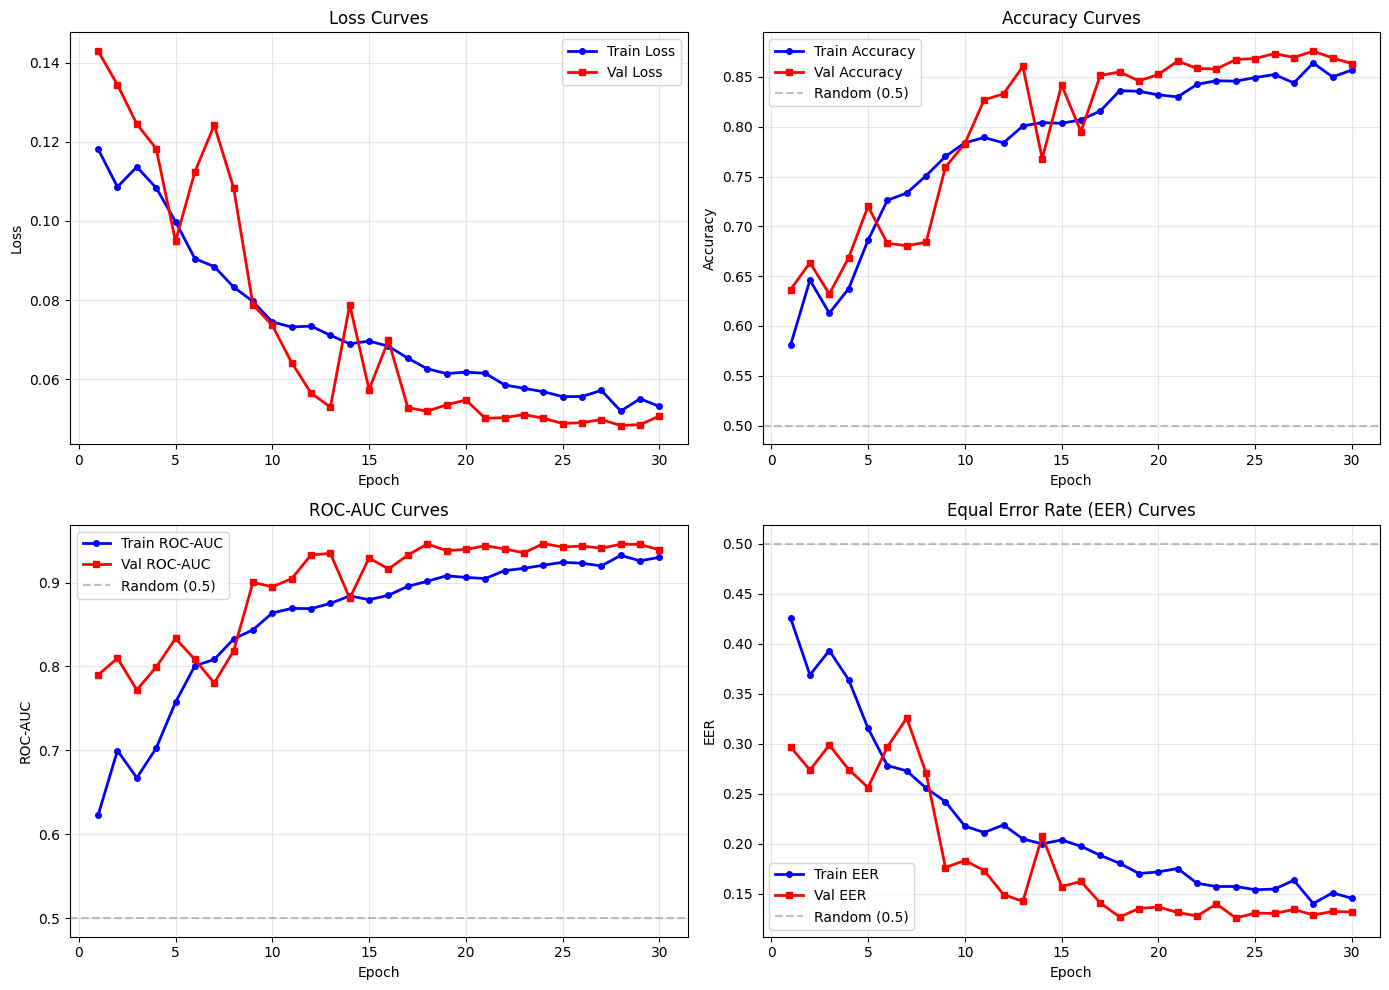

In [ ]:
epochs = range(1, len(history_not_freezed['train_loss']) + 1)

train_loss = history_not_freezed['train_loss']
val_loss = history_not_freezed['val_loss']
train_acc = history_not_freezed['train_acc']
val_acc = history_not_freezed['val_acc']
train_roc_auc = history_not_freezed['train_roc_auc']
val_roc_auc = history_not_freezed['val_roc_auc']
train_eer = history_not_freezed['train_eer']
val_eer = history_not_freezed['val_eer']
lr = history_not_freezed['lr']

# Create figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss Curves
axes[0, 0].plot(epochs, train_loss, 'b-o', label='Train Loss', linewidth=2, markersize=4)
axes[0, 0].plot(epochs, val_loss, 'r-s', label='Val Loss', linewidth=2, markersize=4)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curves')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Accuracy Curves
axes[0, 1].plot(epochs, train_acc, 'b-o', label='Train Accuracy', linewidth=2, markersize=4)
axes[0, 1].plot(epochs, val_acc, 'r-s', label='Val Accuracy', linewidth=2, markersize=4)
axes[0, 1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy Curves')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. ROC-AUC Curves
axes[1, 0].plot(epochs, train_roc_auc, 'b-o', label='Train ROC-AUC', linewidth=2, markersize=4)
axes[1, 0].plot(epochs, val_roc_auc, 'r-s', label='Val ROC-AUC', linewidth=2, markersize=4)
axes[1, 0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('ROC-AUC')
axes[1, 0].set_title('ROC-AUC Curves')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. EER Curves
axes[1, 1].plot(epochs, train_eer, 'b-o', label='Train EER', linewidth=2, markersize=4)
axes[1, 1].plot(epochs, val_eer, 'r-s', label='Val EER', linewidth=2, markersize=4)
axes[1, 1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('EER')
axes[1, 1].set_title('Equal Error Rate (EER) Curves')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_metrics_not_freezed.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
model_not_freezed = model_not_freezed.to(device)

In [ ]:
result = evaluate_siamese_model(model_not_freezed, test_loader, device)


print(f"ROC-AUC: {result['roc_auc']:.4f}")
print(f"EER (Equal Error Rate): {result['eer']:.4f}")
print(f"Accuracy: {result['accuracy']:.4f}")
print(f"Mean distance (positive pair): {result['mean_distance_same_author']:.4f}")
print(f"Mean distance (negative pair): {result['mean_distance_diff_author']:.4f}")



ROC-AUC: 0.9428
EER (Equal Error Rate): 0.1211
Accuracy: 0.7120
Среднее расстояние (позитивная пара): 0.1890
Среднее расстояние (негативная пара): 0.8952


Now let's train the model with moderate freezing mode

In [ ]:
model_mod_freezed = SiameseNetwork(embedding_size=256, freeze_mode='moderate')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Train
history_mod_freezed = train_model(
    model=model_mod_freezed,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=30,
    lr=0.001,
    device=device,
    save_path='best_model_mod_freezed.pth',
    weight_decay=0.0001)

print(f"\nBest Val ROC-AUC: {max(history_mod_freezed['val_roc_auc'])*100:.2f}%")

Freeze mode: moderate
Total parameters: 25,862,336
Trainable parameters: 24,426,816 (94.4%)


Epoch 1/30 [Val]: 100%|██████████| 250/250 [00:28<00:00,  8.68it/s]



Epoch 1/30
  Train Loss: 0.1130, Train Acc: 0.6190, ROC-AUC: 0.6725, EER: 0.6222
  Val Loss:   0.0941, Val Acc:   0.7510, ROC-AUC: 0.8299, EER: 0.7480
  LR: 0.001000
Model saved. Val Acc: 0.7510, Val ROC-AUC: 0.8299, Val EER: 0.7480


Epoch 2/30 [Val]: 100%|██████████| 250/250 [00:28<00:00,  8.66it/s]



Epoch 2/30
  Train Loss: 0.0986, Train Acc: 0.6902, ROC-AUC: 0.7610, EER: 0.6894
  Val Loss:   0.0837, Val Acc:   0.7610, ROC-AUC: 0.8815, EER: 0.8010
  LR: 0.001000
Model saved. Val Acc: 0.7610, Val ROC-AUC: 0.8815, Val EER: 0.8010


...


Epoch 28/30
  Train Loss: 0.0484, Train Acc: 0.8808, ROC-AUC: 0.9404, EER: 0.8730
  Val Loss:   0.0432, Val Acc:   0.8860, ROC-AUC: 0.9548, EER: 0.8880
  LR: 0.000500
Model saved. Val Acc: 0.8860, Val ROC-AUC: 0.9548, Val EER: 0.8880


Epoch 29/30 [Val]: 100%|██████████| 250/250 [00:28<00:00,  8.81it/s]



Epoch 29/30
  Train Loss: 0.0477, Train Acc: 0.8784, ROC-AUC: 0.9443, EER: 0.8762
  Val Loss:   0.0440, Val Acc:   0.8885, ROC-AUC: 0.9502, EER: 0.8885
  LR: 0.000500


Epoch 30/30 [Val]: 100%|██████████| 250/250 [00:28<00:00,  8.81it/s]



Epoch 30/30
  Train Loss: 0.0462, Train Acc: 0.8824, ROC-AUC: 0.9477, EER: 0.8774
  Val Loss:   0.0437, Val Acc:   0.8880, ROC-AUC: 0.9512, EER: 0.8810
  LR: 0.000500

Best Val ROC-AUC: 95.48%


In [ ]:
history_mod_freezed

{'train_loss': [0.11298025495409965,
  0.09859319339394569,
  0.08997843344211578,
  0.08879518852233886,
  0.08349927877485752,
  0.08031225843429565,
  0.07718293108344078,
  0.07488773667775095,
  0.07577889919430017,
  0.07235127672180533,
  0.07564689738377929,
  0.07337639109045267,
  0.07103140487074852,
  0.0708375078111887,
  0.06874952035546303,
  0.06585561165511608,
  0.06573492964506149,
  0.0639161147326231,
  0.06142101923376322,
  0.05867352616004646,
  0.058641072306782005,
  0.057157544413208965,
  0.05286423270367086,
  0.05151078973002732,
  0.05152229049876332,
  0.04997419026661664,
  0.04803832058981061,
  0.04842315800301731,
  0.047718685024790465,
  0.04618593936553225],
 'val_loss': [0.09413291743211448,
  0.0837061048168689,
  0.09156171488342807,
  0.08116718983650208,
  0.08716553902626037,
  0.08634450403973461,
  0.0678369094915688,
  0.06686037519667297,
  0.059270488208159805,
  0.07606214302498847,
  0.05540610008314252,
  0.05517546316888183,
  0.054

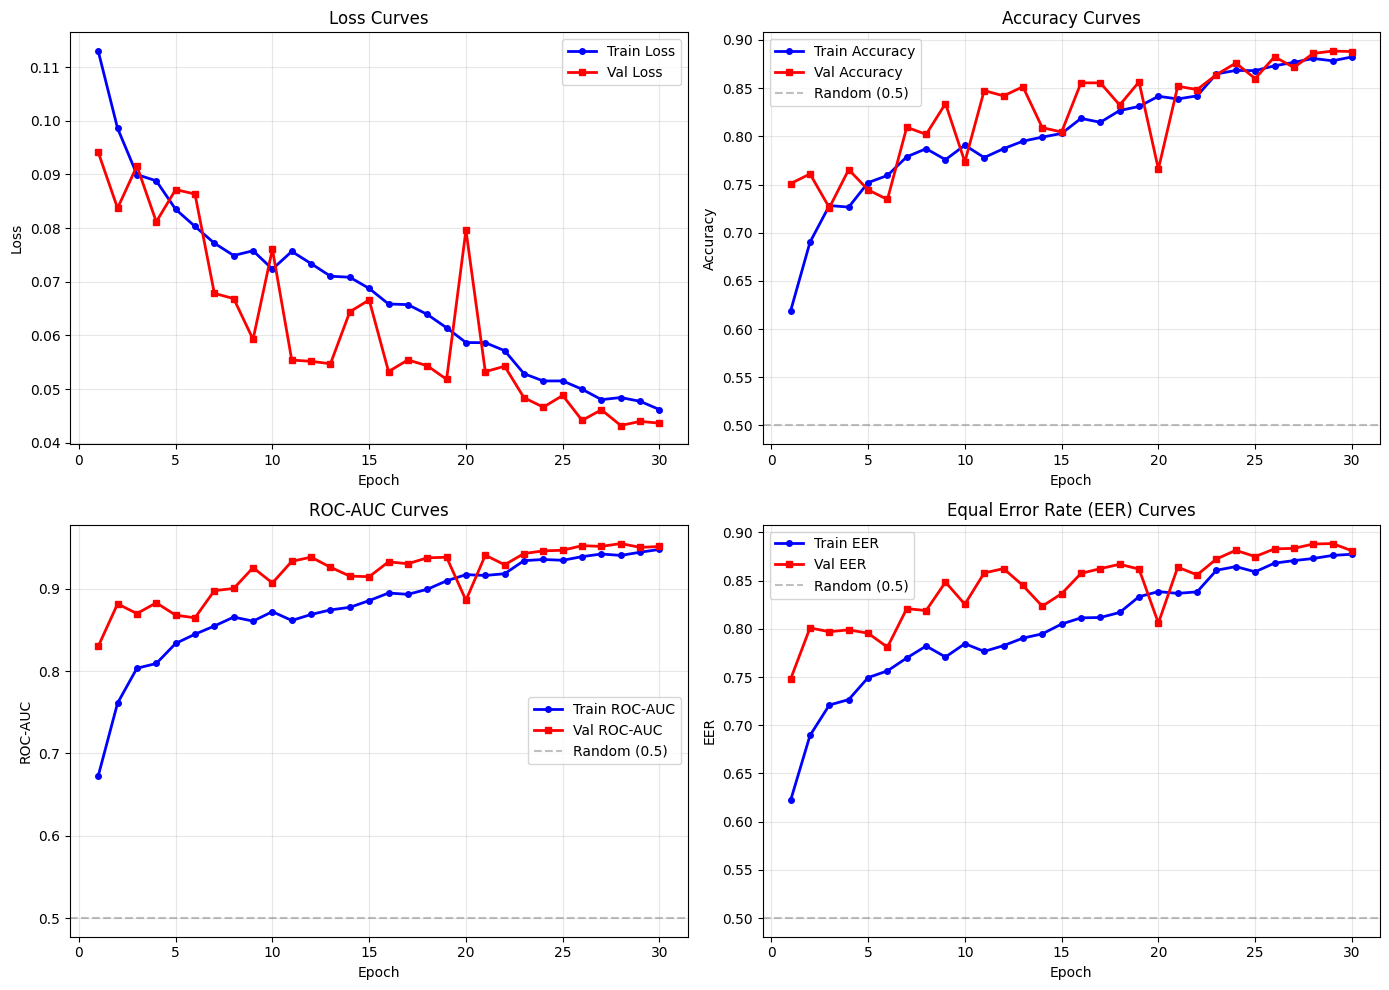

In [ ]:
epochs = range(1, len(history_mod_freezed['train_loss']) + 1)

train_loss = history_mod_freezed['train_loss']
val_loss = history_mod_freezed['val_loss']
train_acc = history_mod_freezed['train_acc']
val_acc = history_mod_freezed['val_acc']
train_roc_auc = history_mod_freezed['train_roc_auc']
val_roc_auc = history_mod_freezed['val_roc_auc']
train_eer = history_mod_freezed['train_eer']
val_eer = history_mod_freezed['val_eer']
lr = history_mod_freezed['lr']

# Create figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Loss Curves
axes[0, 0].plot(epochs, train_loss, 'b-o', label='Train Loss', linewidth=2, markersize=4)
axes[0, 0].plot(epochs, val_loss, 'r-s', label='Val Loss', linewidth=2, markersize=4)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curves')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Accuracy Curves
axes[0, 1].plot(epochs, train_acc, 'b-o', label='Train Accuracy', linewidth=2, markersize=4)
axes[0, 1].plot(epochs, val_acc, 'r-s', label='Val Accuracy', linewidth=2, markersize=4)
axes[0, 1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy Curves')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. ROC-AUC Curves
axes[1, 0].plot(epochs, train_roc_auc, 'b-o', label='Train ROC-AUC', linewidth=2, markersize=4)
axes[1, 0].plot(epochs, val_roc_auc, 'r-s', label='Val ROC-AUC', linewidth=2, markersize=4)
axes[1, 0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('ROC-AUC')
axes[1, 0].set_title('ROC-AUC Curves')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. EER Curves
axes[1, 1].plot(epochs, train_eer, 'b-o', label='Train EER', linewidth=2, markersize=4)
axes[1, 1].plot(epochs, val_eer, 'r-s', label='Val EER', linewidth=2, markersize=4)
axes[1, 1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('EER')
axes[1, 1].set_title('Equal Error Rate (EER) Curves')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_metrics_mod_freezed.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
model_mod_freezed = model_mod_freezed.to(device)

In [ ]:
result = evaluate_siamese_model(model_mod_freezed, test_loader, device)


print(f"ROC-AUC: {result['roc_auc']:.4f}")
print(f"EER (Equal Error Rate): {result['eer']:.4f}")
print(f"Accuracy: {result['accuracy']:.4f}")
print(f"Среднее расстояние (позитивная пара): {result['mean_distance_same_author']:.4f}")
print(f"Среднее расстояние (негативная пара): {result['mean_distance_diff_author']:.4f}")



ROC-AUC: 0.9553
EER (Equal Error Rate): 0.1091
Accuracy: 0.7440
Среднее расстояние (позитивная пара): 0.2059
Среднее расстояние (негативная пара): 0.9342


Now let's test our model on separate datasets, ICDAR (dutch and chinese parts separately) and CVL.
First we create fixed pairs from these datasets to reuse the same dataset on all models

In [13]:
#importing dataset
file_id = "1JJuTbRRBaCgm3UjjHnFmHOaH_vZo4zsk"
output_name = "icdar_chinese.zip"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1JJuTbRRBaCgm3UjjHnFmHOaH_vZo4zsk
From (redirected): https://drive.google.com/uc?id=1JJuTbRRBaCgm3UjjHnFmHOaH_vZo4zsk&confirm=t&uuid=9f9dd6ca-a55b-4144-a16d-53aa763b6449
To: /content/icdar_chinese.zip
100% 405M/405M [00:06<00:00, 64.1MB/s]


In [14]:
with zipfile.ZipFile("icdar_chinese.zip", 'r') as zip_ref:
    zip_ref.extractall("/kaggle/working/")
os.listdir("/kaggle/working/")

['all_data_3', 'icdar_chinese']

In [15]:
DATA_ROOT_icdar_chinese = "/kaggle/working/icdar_chinese"

In [16]:
class ICDARDataset(Dataset):
    def __init__(self, root, transform=None, size=100, authors_list=None):
        """
        Dataset for ICDAR signatures with Contrastive Loss.

        Args:
            root: Root directory containing author folders with 'genuine' and 'forge' subfolders
            transform: Image transformations
            size: Number of pairs per epoch
            authors_list: List of author IDs to include (for train/val split)
        """
        self.transform = transform
        self.size = size

        # Data structures
        self.genuine_images = {}  # author_id -> list of genuine image paths
        self.forged_images = {}   # author_id -> list of forged image paths

        # Scan author folders
        for author_id in os.listdir(root):
            author_path = os.path.join(root, author_id)
            if not os.path.isdir(author_path):
                continue

            # Filter by authors_list if provided
            if authors_list is not None and author_id not in authors_list:
                continue

            # Scan genuine folder
            genuine_path = os.path.join(author_path, 'genuine')
            if os.path.exists(genuine_path):
                valid_images = []
                for file in os.listdir(genuine_path):
                    if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
                        continue
                    img_path = os.path.join(genuine_path, file)
                    try:
                        with Image.open(img_path) as img:
                            img.verify()
                        valid_images.append(img_path)
                    except Exception:
                        continue
                if valid_images:
                    self.genuine_images[author_id] = valid_images

            # Scan forge folder
            forge_path = os.path.join(author_path, 'forge')
            if os.path.exists(forge_path):
                valid_images = []
                for file in os.listdir(forge_path):
                    if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
                        continue
                    img_path = os.path.join(forge_path, file)
                    try:
                        with Image.open(img_path) as img:
                            img.verify()
                        valid_images.append(img_path)
                    except Exception:
                        continue
                if valid_images:
                    self.forged_images[author_id] = valid_images

        # Build author lists
        # For positive pairs: need at least 2 genuine images
        self.positive_authors = [a for a, imgs in self.genuine_images.items() if len(imgs) >= 2]

        # For negative pairs: need at least 1 genuine and 1 forged
        self.negative_authors = [a for a in self.genuine_images.keys()
                                  if a in self.forged_images
                                  and len(self.genuine_images[a]) >= 1
                                  and len(self.forged_images[a]) >= 1]

        # All authors for potential use
        self.all_authors = list(self.genuine_images.keys())

        # Print statistics
        total_genuine = sum(len(v) for v in self.genuine_images.values())
        total_forged = sum(len(v) for v in self.forged_images.values())

    def __len__(self):
        return self.size

    def _get_positive_pair(self):
        """Return two genuine signatures from same author (label=1)"""
        author = random.choice(self.positive_authors)
        images = self.genuine_images[author]
        img1_path, img2_path = random.sample(images, 2)
        return img1_path, img2_path, 1

    def _get_negative_pair(self):
        """Return genuine vs forged signature from same author (label=0)"""
        if not self.negative_authors:
            # Fallback: different authors if no forgeries available
            return self._get_different_authors_pair()

        author = random.choice(self.negative_authors)
        genuine_images = self.genuine_images[author]
        forged_images = self.forged_images[author]

        img1_path = random.choice(genuine_images)
        img2_path = random.choice(forged_images)
        return img1_path, img2_path, 0

    def _get_different_authors_pair(self):
        """Fallback: return genuine signatures from different authors (label=0)"""
        if len(self.all_authors) < 2:
            # Ultimate fallback: positive pair
            return self._get_positive_pair()

        author1, author2 = random.sample(self.all_authors, 2)
        img1_path = random.choice(self.genuine_images[author1])
        img2_path = random.choice(self.genuine_images[author2])
        return img1_path, img2_path, 0

    def __getitem__(self, idx):
        # 50% positive pairs (genuine vs genuine), 50% negative pairs (genuine vs forged)
        if random.random() < 0.5:
            img1_path, img2_path, label = self._get_positive_pair()
        else:
            img1_path, img2_path, label = self._get_negative_pair()

        # Load images
        img1 = Image.open(img1_path).convert('L')
        img2 = Image.open(img2_path).convert('L')

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, label, img1_path, img2_path

In [17]:

# icdar_chinese_pairs = []
# temp_dataset_icdar_chinese = ICDARDataset(root=DATA_ROOT_icdar_chinese, transform=None,
#                               size=5000)

# for i in range(len(temp_dataset_icdar_chinese)):
#     img1, img2, label, p1, p2 = temp_dataset_icdar_chinese[i]
#     icdar_chinese_pairs.append((p1, p2, label))

# with open('icdar_chinese_pairs.pkl', 'wb') as f:
#     pickle.dump(icdar_chinese_pairs, f)

test_icdar_chinese_dataset = SavedPairsDataset('icdar_chinese_pairs.pkl', transform=test_transform)

In [ ]:
labels_icdar_chinese=[]

for i in range(len(test_icdar_chinese_dataset)):
  labels_icdar_chinese.append(test_icdar_chinese_dataset[i][2])

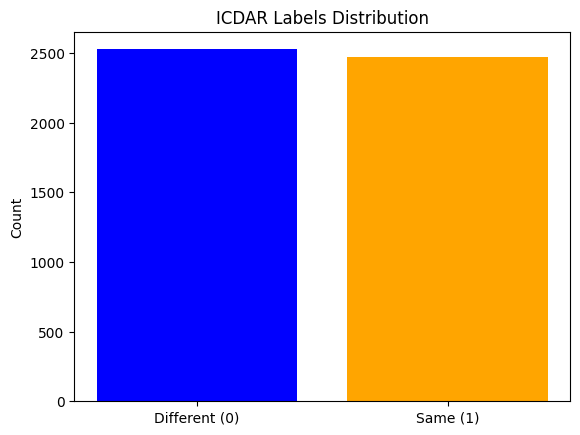

In [ ]:
counts = [labels_icdar_chinese.count(0), labels_icdar_chinese.count(1)]

plt.bar(['Different (0)', 'Same (1)'], counts, color=['blue', 'orange'])
plt.ylabel('Count')
plt.title('ICDAR Labels Distribution')
plt.show()

In [37]:
test_icdar_chinese_loader = DataLoader(
    dataset=test_icdar_chinese_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

Label: 1, /kaggle/working/icdar_chinese/013/genuine/04_013.png, /kaggle/working/icdar_chinese/013/genuine/01_013.png
Size img1: torch.Size([1, 224, 224])
Size img2: torch.Size([1, 224, 224])


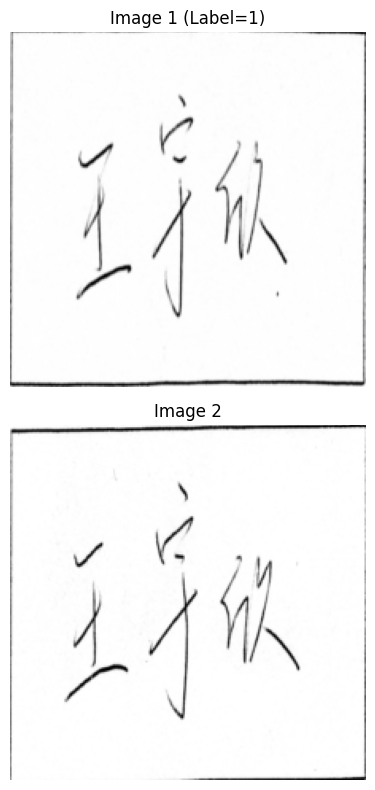

In [ ]:
img1, img2, label = test_icdar_chinese_dataset[5]

print(f"Label: {label}, {p1}, {p2}")
print(f"Size img1: {img1.shape}")
print(f"Size img2: {img2.shape}")

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.imshow(img1[0], cmap='gray')
plt.title(f"Image 1 (Label={label})")
plt.axis('off')

plt.subplot(2, 1, 2)
plt.imshow(img2[0], cmap='gray')
plt.title("Image 2")
plt.axis('off')

plt.tight_layout()
plt.show()

In [18]:
#importing dataset

file_id = "1R3EIjJEl2Fib0zFuacCJrTbR19x5ESoK"
output_name = "icdar_dutch.zip"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1R3EIjJEl2Fib0zFuacCJrTbR19x5ESoK
From (redirected): https://drive.google.com/uc?id=1R3EIjJEl2Fib0zFuacCJrTbR19x5ESoK&confirm=t&uuid=97d8e324-47ab-466b-a7ed-f72d28e2a158
To: /content/icdar_dutch.zip
100% 388M/388M [00:04<00:00, 92.9MB/s]


In [19]:
import zipfile
import os

with zipfile.ZipFile("icdar_dutch.zip", 'r') as zip_ref:
    zip_ref.extractall("/kaggle/working/")

# Посмотрите, что получилось
os.listdir("/kaggle/working/")

['all_data_3', 'icdar_chinese', 'icdar_dutch']

In [20]:
DATA_ROOT_icdar_dutch = "/kaggle/working/icdar_dutch"

In [21]:
# # Создание и сохранение
# icdar_dutch_pairs = []
# temp_dataset_icdar_dutch = ICDARDataset(root=DATA_ROOT_icdar_dutch, transform=None,
#                               size=5000)

# for i in range(len(temp_dataset_icdar_dutch)):
#     img1, img2, label, p1, p2 = temp_dataset_icdar_dutch[i]
#     icdar_dutch_pairs.append((p1, p2, label))

# with open('icdar_dutch_pairs.pkl', 'wb') as f:
#     pickle.dump(icdar_dutch_pairs, f)

test_icdar_dutch_dataset = SavedPairsDataset('icdar_dutch_pairs.pkl', transform=test_transform)

In [ ]:
labels_icdar_dutch=[]

for i in range(len(test_icdar_dutch_dataset)):
  labels_icdar_dutch.append(test_icdar_dutch_dataset[i][2])

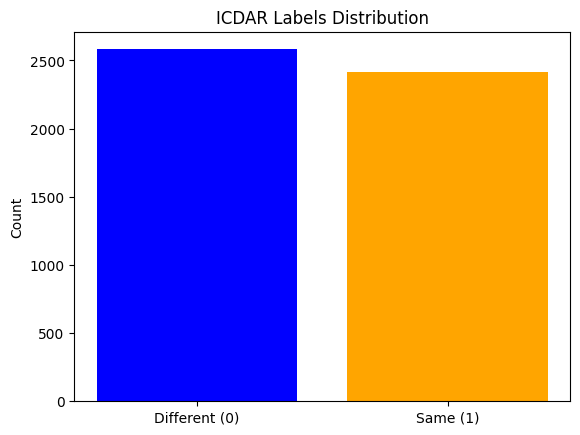

In [ ]:
counts = [labels_icdar_dutch.count(0), labels_icdar_dutch.count(1)]

plt.bar(['Different (0)', 'Same (1)'], counts, color=['blue', 'orange'])
plt.ylabel('Count')
plt.title('ICDAR Labels Distribution')
plt.show()

In [22]:
test_icdar_dutch_loader = DataLoader(
    dataset=test_icdar_dutch_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

Label: 0, /kaggle/working/icdar_dutch/043/genuine/24_043.PNG, /kaggle/working/icdar_dutch/043/forge/04_0111043.PNG
Size img1: torch.Size([1, 224, 224])
Size img2: torch.Size([1, 224, 224])


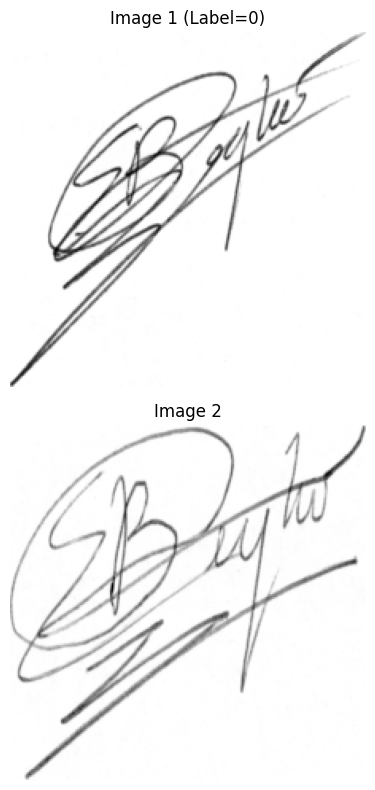

In [ ]:
img1, img2, label = test_icdar_dutch_dataset[1]

print(f"Label: {label}, {p1}, {p2}")
print(f"Size img1: {img1.shape}")
print(f"Size img2: {img2.shape}")

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.imshow(img1[0], cmap='gray')
plt.title(f"Image 1 (Label={label})")
plt.axis('off')

plt.subplot(2, 1, 2)
plt.imshow(img2[0], cmap='gray')
plt.title("Image 2")
plt.axis('off')

plt.tight_layout()
plt.show()

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [10]:
checkpoint_agr = torch.load('best_model_agr_freezed (2).pth', map_location='cpu', weights_only=False)
checkpoint_mod = torch.load('best_model_mod_freezed (1).pth', map_location='cpu', weights_only=False)
checkpoint_none = torch.load('best_model_not_freezed (3).pth', map_location='cpu', weights_only=False)

In [11]:
model_agr = SiameseNetwork(embedding_size=256, freeze_mode='aggressive')
model_agr.load_state_dict(checkpoint_agr['model_state_dict'])
model_agr.eval()

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 121MB/s]


Freeze mode: aggressive
Total parameters: 25,862,336
Trainable parameters: 17,328,448 (67.0%)


SiameseNetwork(
  (resnet): Sequential(
    (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2

In [12]:
model_agr_c_b=model_agr.to(device)

In [13]:
model_mod = SiameseNetwork(embedding_size=256, freeze_mode='moderate')
model_mod.load_state_dict(checkpoint_mod['model_state_dict'])
model_mod.eval()

Freeze mode: moderate
Total parameters: 25,862,336
Trainable parameters: 24,426,816 (94.4%)


SiameseNetwork(
  (resnet): Sequential(
    (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2

In [14]:
model_mod_c_b=model_mod.to(device)

In [15]:
model_none = SiameseNetwork(embedding_size=256, freeze_mode=None)
model_none.load_state_dict(checkpoint_none['model_state_dict'])
model_none.eval()

Freeze mode: None
Total parameters: 25,862,336
Trainable parameters: 25,862,336 (100.0%)


SiameseNetwork(
  (resnet): Sequential(
    (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2

In [16]:
model_none=model_none.to(device)

In [38]:
result_icdar_chinese_agr = evaluate_siamese_model(model_agr, test_icdar_chinese_loader, device)

print(f"\nRESULTS:")
print(f"ROC-AUC: {result_icdar_chinese_agr['roc_auc']:.4f}")
print(f"Accuracy (threshold=0.5): {result_icdar_chinese_agr['accuracy']:.4f}")
print(f"EER: {result_icdar_chinese_agr['eer']:.4f}")
print(f"Mean distance (positive pair): {result_icdar_chinese_agr['mean_distance_same_author']:.4f}")
print(f"Mean distance (negative pair): {result_icdar_chinese_agr['mean_distance_diff_author']:.4f}")
print(f"Samples: {result_icdar_chinese_agr['num_samples']} (pos={result_icdar_chinese_agr['num_positive']}, neg={result_icdar_chinese_agr['num_negative']})")


RESULTS:
ROC-AUC: 0.6056
Accuracy (threshold=0.5): 0.4948
EER: 0.4246
Mean distance (positive pair): 0.2569
Mean distance (negative pair): 0.3248
Samples: 5000 (pos=2473, neg=2527)


In [39]:
result_icdar_dutch_agr = evaluate_siamese_model(model_agr, test_icdar_dutch_loader, device)

print(f"\nRESULTS:")
print(f"ROC-AUC: {result_icdar_dutch_agr['roc_auc']:.4f}")
print(f"Accuracy (threshold=0.5): {result_icdar_dutch_agr['accuracy']:.4f}")
print(f"EER: {result_icdar_dutch_agr['eer']:.4f}")
print(f"Mean distance (positive pair): {result_icdar_dutch_agr['mean_distance_same_author']:.4f}")
print(f"Mean distance (negative pair): {result_icdar_dutch_agr['mean_distance_diff_author']:.4f}")
print(f"Samples: {result_icdar_dutch_agr['num_samples']} (pos={result_icdar_dutch_agr['num_positive']}, neg={result_icdar_dutch_agr['num_negative']})")


RESULTS:
ROC-AUC: 0.6871
Accuracy (threshold=0.5): 0.5068
EER: 0.3654
Mean distance (positive pair): 0.2879
Mean distance (negative pair): 0.4644
Samples: 5000 (pos=2418, neg=2582)


In [40]:
result_icdar_chinese_mod = evaluate_siamese_model(model_mod, test_icdar_chinese_loader, device)

print(f"\nRESULTS:")
print(f"ROC-AUC: {result_icdar_chinese_mod['roc_auc']:.4f}")
print(f"Accuracy (threshold=0.5): {result_icdar_chinese_mod['accuracy']:.4f}")
print(f"EER: {result_icdar_chinese_mod['eer']:.4f}")
print(f"Mean distance (positive pair): {result_icdar_chinese_mod['mean_distance_same_author']:.4f}")
print(f"Mean distance (negative pair): {result_icdar_chinese_mod['mean_distance_diff_author']:.4f}")
print(f"Samples: {result_icdar_chinese_mod['num_samples']} (pos={result_icdar_chinese_mod['num_positive']}, neg={result_icdar_chinese_mod['num_negative']})")


RESULTS:
ROC-AUC: 0.6084
Accuracy (threshold=0.5): 0.4946
EER: 0.4170
Mean distance (positive pair): 0.2186
Mean distance (negative pair): 0.2913
Samples: 5000 (pos=2473, neg=2527)


In [41]:
result_icdar_dutch_mod = evaluate_siamese_model(model_mod, test_icdar_dutch_loader, device)

print(f"\nRESULTS:")
print(f"ROC-AUC: {result_icdar_dutch_mod['roc_auc']:.4f}")
print(f"Accuracy (threshold=0.5): {result_icdar_dutch_mod['accuracy']:.4f}")
print(f"EER: {result_icdar_dutch_mod['eer']:.4f}")
print(f"Mean distance (positive pair): {result_icdar_dutch_mod['mean_distance_same_author']:.4f}")
print(f"Mean distance (negative pair): {result_icdar_dutch_mod['mean_distance_diff_author']:.4f}")
print(f"Samples: {result_icdar_dutch_mod['num_samples']} (pos={result_icdar_dutch_mod['num_positive']}, neg={result_icdar_dutch_mod['num_negative']})")


RESULTS:
ROC-AUC: 0.7374
Accuracy (threshold=0.5): 0.5454
EER: 0.3318
Mean distance (positive pair): 0.1738
Mean distance (negative pair): 0.4527
Samples: 5000 (pos=2418, neg=2582)


In [42]:
result_icdar_chinese_none = evaluate_siamese_model(model_none, test_icdar_chinese_loader, device)

print(f"\nRESULTS:")
print(f"ROC-AUC: {result_icdar_chinese_none['roc_auc']:.4f}")
print(f"Accuracy (threshold=0.5): {result_icdar_chinese_none['accuracy']:.4f}")
print(f"EER: {result_icdar_chinese_none['eer']:.4f}")
print(f"Mean distance (positive pair): {result_icdar_chinese_none['mean_distance_same_author']:.4f}")
print(f"Mean distance (negative pair): {result_icdar_chinese_none['mean_distance_diff_author']:.4f}")
print(f"Samples: {result_icdar_chinese_none['num_samples']} (pos={result_icdar_chinese_none['num_positive']}, neg={result_icdar_chinese_none['num_negative']})")


RESULTS:
ROC-AUC: 0.6300
Accuracy (threshold=0.5): 0.4950
EER: 0.4082
Mean distance (positive pair): 0.2177
Mean distance (negative pair): 0.3081
Samples: 5000 (pos=2473, neg=2527)


In [43]:
result_icdar_dutch_none = evaluate_siamese_model(model_none, test_icdar_dutch_loader, device)

print(f"\nRESULTS:")
print(f"ROC-AUC: {result_icdar_dutch_none['roc_auc']:.4f}")
print(f"Accuracy (threshold=0.5): {result_icdar_dutch_none['accuracy']:.4f}")
print(f"EER: {result_icdar_dutch_none['eer']:.4f}")
print(f"Mean distance (positive pair): {result_icdar_dutch_none['mean_distance_same_author']:.4f}")
print(f"Mean distance (negative pair): {result_icdar_dutch_none['mean_distance_diff_author']:.4f}")
print(f"Samples: {result_icdar_dutch_none['num_samples']} (pos={result_icdar_dutch_none['num_positive']}, neg={result_icdar_dutch_none['num_negative']})")


RESULTS:
ROC-AUC: 0.8419
Accuracy (threshold=0.5): 0.5262
EER: 0.2276
Mean distance (positive pair): 0.1638
Mean distance (negative pair): 0.5073
Samples: 5000 (pos=2418, neg=2582)


In [17]:
file_id = "17qUpD1PYlT3d4MkZ6OXeIhb8gqD5F0mZ"
output_name = "cvl.zip"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=17qUpD1PYlT3d4MkZ6OXeIhb8gqD5F0mZ
From (redirected): https://drive.google.com/uc?id=17qUpD1PYlT3d4MkZ6OXeIhb8gqD5F0mZ&confirm=t&uuid=2e21919b-5b2d-4d82-8fc8-5a2c4fc0ea85
To: /content/cvl.zip
100% 277M/277M [00:05<00:00, 55.1MB/s]


In [18]:
import zipfile
import os

with zipfile.ZipFile("cvl.zip", 'r') as zip_ref:
    zip_ref.extractall("/kaggle/working/")

# Посмотрите, что получилось
os.listdir("/kaggle/working/")

['cvl']

In [19]:
DATA_ROOT_cvl = "/kaggle/working/cvl"

In [ ]:
import os
import random
from PIL import Image
from torch.utils.data import Dataset

class CVLDataset(Dataset):
    def __init__(self, root, transform=None, size=100, authors_list=None):
        """
        Dataset for CVL handwriting images.

        Args:
            root: Root directory containing author folders with .tif images
            transform: Image transformations
            size: Number of pairs per epoch
            authors_list: List of author IDs to include (for train/val split)
        """
        self.transform = transform
        self.size = size

        # Data structure: author_id -> list of image paths
        self.author_images = {}

        # Scan author folders
        for author_id in os.listdir(root):
            author_path = os.path.join(root, author_id)
            if not os.path.isdir(author_path):
                continue

            # Filter by authors_list if provided
            if authors_list is not None and author_id not in authors_list:
                continue

            valid_images = []
            for file in os.listdir(author_path):
                if not file.lower().endswith(('.tif', '.tiff', '.png', '.jpg', '.jpeg')):
                    continue

                img_path = os.path.join(author_path, file)
                try:
                    with Image.open(img_path) as img:
                        img.verify()
                    valid_images.append(img_path)
                except Exception:
                    continue

            if valid_images:
                self.author_images[author_id] = valid_images

        # Build author lists
        # For positive pairs: need at least 2 images per author
        self.positive_authors = [a for a, imgs in self.author_images.items() if len(imgs) >= 2]

        # All authors for negative sampling
        self.all_authors = list(self.author_images.keys())

    def __len__(self):
        return self.size

    def _get_positive_pair(self):
        """Return two images from same author (label=1)"""
        author = random.choice(self.positive_authors)
        images = self.author_images[author]
        img1_path, img2_path = random.sample(images, 2)
        label = 1
        return img1_path, img2_path, label

    def _get_negative_pair(self):
        """Return images from two different authors (label=0)"""
        author1, author2 = random.sample(self.all_authors, 2)
        img1_path = random.choice(self.author_images[author1])
        img2_path = random.choice(self.author_images[author2])
        label = 0
        return img1_path, img2_path, label

    def __getitem__(self, idx):
        # 50% positive pairs, 50% negative pairs
        if random.random() < 0.5:
            img1_path, img2_path, label = self._get_positive_pair()
        else:
            img1_path, img2_path, label = self._get_negative_pair()

        # Load images
        img1 = Image.open(img1_path).convert('L')
        img2 = Image.open(img2_path).convert('L')

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, label, img1_path, img2_path

In [20]:
# # Создание и сохранение
# cvl_pairs = []
# temp_dataset_cvl = CVLDataset(root=DATA_ROOT_cvl, transform=None,
#                               size=5000)

# for i in range(len(temp_dataset_cvl)):
#     img1, img2, label, p1, p2 = temp_dataset_cvl[i]
#     cvl_pairs.append((p1, p2, label))

# with open('cvl_pairs.pkl', 'wb') as f:
#     pickle.dump(cvl_pairs, f)

test_cvl_dataset = SavedPairsDataset('cvl_pairs.pkl', transform=test_transform)

Label: 1
Size img1: torch.Size([1, 224, 224])
Size img2: torch.Size([1, 224, 224])


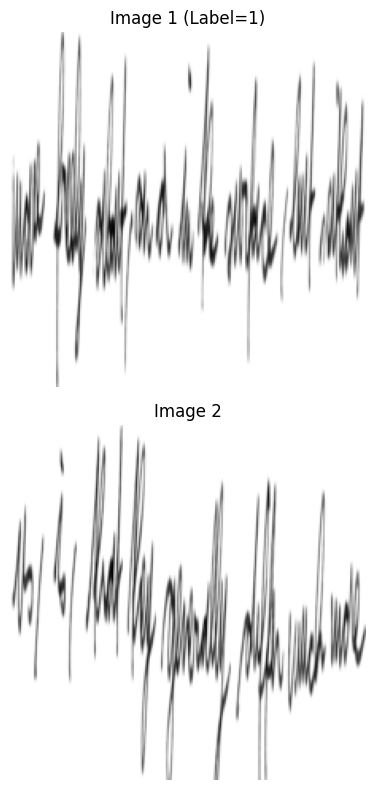

In [21]:
img1, img2, label = test_cvl_dataset[0]

print(f"Label: {label}")
print(f"Size img1: {img1.shape}")
print(f"Size img2: {img2.shape}")

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.imshow(img1[0], cmap='gray')
plt.title(f"Image 1 (Label={label})")
plt.axis('off')

plt.subplot(2, 1, 2)
plt.imshow(img2[0], cmap='gray')
plt.title("Image 2")
plt.axis('off')

plt.tight_layout()
plt.show()

In [22]:
test_cvl_loader = DataLoader(
    dataset=test_cvl_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [23]:
result_cvl_agr = evaluate_siamese_model(model_agr, test_cvl_loader, device)

print(f"\nRESULTS:")
print(f"ROC-AUC: {result_cvl_agr['roc_auc']:.4f}")
print(f"Accuracy (threshold=0.5): {result_cvl_agr['accuracy']:.4f}")
print(f"EER: {result_cvl_agr['eer']:.4f}")
print(f"Mean distance (positive pair): {result_cvl_agr['mean_distance_same_author']:.4f}")
print(f"Mean distance (negative pair): {result_cvl_agr['mean_distance_diff_author']:.4f}")
print(f"Samples: {result_cvl_agr['num_samples']} (pos={result_cvl_agr['num_positive']}, neg={result_cvl_agr['num_negative']})")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



RESULTS:
ROC-AUC: 0.6129
Accuracy (threshold=0.5): 0.5182
EER: 0.4142
Mean distance (positive pair): 0.2876
Mean distance (negative pair): 0.3834
Samples: 5000 (pos=2546, neg=2454)


In [24]:
result_cvl_mod = evaluate_siamese_model(model_mod, test_cvl_loader, device)

print(f"\nRESULTS:")
print(f"ROC-AUC: {result_cvl_mod['roc_auc']:.4f}")
print(f"Accuracy (threshold=0.5): {result_cvl_mod['accuracy']:.4f}")
print(f"EER: {result_cvl_mod['eer']:.4f}")
print(f"Mean distance (positive pair): {result_cvl_mod['mean_distance_same_author']:.4f}")
print(f"Mean distance (negative pair): {result_cvl_mod['mean_distance_diff_author']:.4f}")
print(f"Samples: {result_cvl_mod['num_samples']} (pos={result_cvl_mod['num_positive']}, neg={result_cvl_mod['num_negative']})")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



RESULTS:
ROC-AUC: 0.6338
Accuracy (threshold=0.5): 0.5092
EER: 0.4130
Mean distance (positive pair): 0.1027
Mean distance (negative pair): 0.1893
Samples: 5000 (pos=2546, neg=2454)


In [25]:
result_cvl_none = evaluate_siamese_model(model_none, test_cvl_loader, device)

print(f"\nRESULTS:")
print(f"ROC-AUC: {result_cvl_none['roc_auc']:.4f}")
print(f"Accuracy (threshold=0.5): {result_cvl_none['accuracy']:.4f}")
print(f"EER: {result_cvl_none['eer']:.4f}")
print(f"Mean distance (positive pair): {result_cvl_none['mean_distance_same_author']:.4f}")
print(f"Mean distance (negative pair): {result_cvl_none['mean_distance_diff_author']:.4f}")
print(f"Samples: {result_cvl_none['num_samples']} (pos={result_cvl_none['num_positive']}, neg={result_cvl_none['num_negative']})")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



RESULTS:
ROC-AUC: 0.6595
Accuracy (threshold=0.5): 0.5106
EER: 0.3908
Mean distance (positive pair): 0.1694
Mean distance (negative pair): 0.2744
Samples: 5000 (pos=2546, neg=2454)
